# Challenger-Layoffs — a quantitative teardown 🔬
### Spike-conditioned split returns · Welch *t* + Newey-West HAC *t* + placebo null · the decisive lead/lag cross-correlation · a timing overlay vs buy-and-hold · robustness · a synthetic planted-edge control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Early_warning%3F: Not_supported](https://img.shields.io/badge/Early_warning%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The believers fuse two claims: that a Challenger job-cut spike (1) **predicts** weaker equity returns and (2) does so **early** enough to trade. We separate them. The conditional return tilt is the *right sign but insignificant*; the decisive object is the **lead/lag structure**, which shows the cut spike is **coincident-to-lagging**, not leading — and a tradable overlay that *underperforms* buy-and-hold seals the Tradability axis.

> ⚠️ **Data + proxy note.** Challenger's series is proprietary with no free feed; the job-cut tape is a hardcoded, **labelled approximate** monthly reconstruction of the public headline totals (thousands announced) — faithful in shape, **not** the exact revised vintage (named on the Signal axis, so magnitude is a proxy result). SPY is yfinance daily adjusted close (total-return), month-end sampled. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from challenger_layoffs import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("SPY cache present:", HAVE_REAL,
      "| cuts+SPY months:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2000-01-31', 'end': '2026-06-30', 'months': 318, 'years': 26.4, 'spike_freq': 41, 'h1': (1, 131, 0.25, 1.16, 0.78, 44, 36, -1.05, -1.66, 0.081), 'h3': (3, 131, 1.7, 2.75, 2.31, 33, 31, -0.73, -0.85, 0.174), 'h6': (6, 131, 3.54, 5.5, 4.67, 33, 27, -0.88, -0.98, 0.12), 'h12': (12, 130, 8.57, 10.63, 9.75, 25, 22, -0.58, -0.61, 0.211), 'leadlag': {-6: -0.099, -5: -0.039, -4: -0.083, -3: -0.236, -2: -0.246, -1: -0.047, 0: 0.015, 1: 0.016, 2: 0.079, 3: 0.088, 4: -0.054, 5: -0.018, 6: 0.056}, 'overlay': (9.3, 0.61, 5.7, 0.55, 5.3, 0.51, 102), 'robust': [('w=6', 139, 7.4, 9.8, -1.25, -1.56, 0.049), ('w=12', 130, 8.6, 9.8, -0.58, -0.61, 0.211), ('w=24', 121, 9.5, 9.8, -0.14, -0.11, 0.421), ('thr>+50%', 34, 13.5, 9.8, 0.98, 0.67, 0.908), ('ex-COVID', 121, 8.7, 10.7, -0.89, -1.03, 0.116)], 'syn': [(0.0, 119, 0.44, 0.66, -0.53, -0.76, 0.277), (0.04, 119, -2.87, -0.65, -5.44, -7.84, 0.001)]}


SPY cache present: True | cuts+SPY months: 318


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | 1-month spike mean **+0.25%** vs base **+0.78%** (right sign, announcement-drift); Welch **t = -1.05**, HAC **t = -1.66**, placebo **p = 0.08** — fails **|t| ≥ 2**, fragile to window, sign-flips for big spikes. |
| **Tradability** | `MIRAGE` | Cash-on-spike overlay **+5.3%/yr** (Sharpe **0.51**) **vs buy-hold +9.3%/yr** (Sharpe **0.61**). Acting on it destroys return. |
| **Early warning?** | `NOT SUPPORTED` | Peak negative lead/lag correlation at **L = −2** (cuts lag the market); at positive leads corr ≈ 0. A coincident-to-lagging echo, not a leader. |

> 💡 In plain words: the equity market *is* a leading indicator of the economy, so a labour series that co-moves with equity weakness need not lead it. The cut spike lines up with a market move already two months old — the 'early-warning' is the market's own lead, reflected back.

## 1 · The claim, steelmanned

Let $x_t$ be monthly announced job cuts and $s_t = x_t / \overline{x}_{t-1:t-12} - 1$ its excess over the trailing-year average. Cuts are **SPIKING** at $t$ when $s_t > 0$. With a one-month execution lag (the month-$t$ report is released early in $t+1$ and acted on at that close), define forward return $r_{t+1\to t+1+H}$.

- **H₁ (predicts).** $\mathbb{E}[r\mid \text{spike}] < \mathbb{E}[r]$ — a *negative* excess over the base rate.
- **H₂ (leads).** The strongest negative spike↔return correlation sits at a **positive** lead (cuts move first).
- **H₃ (deployable).** A cash-on-spike overlay beats buy-and-hold net of costs.

We find **H₁ directionally true but insignificant** (best HAC $t = -1.66$, sign-flips by spec), **H₂ rejected** (peak negative corr at $L=-2$), **H₃ rejected** (overlay underperforms). The folklore is right exactly where it's uninformative (layoffs and recessions co-move) and wrong exactly where it would pay (a *leading*, *tradable* edge).

## 2 · So what? — what rides on each answer

The conditional-return test is a two-sample mean comparison judged by its standard error, and — because forward windows overlap — by a HAC-robust regression *t*:

$$\widehat{\Delta}_H = \bar r^{\text{spike}}_H - \bar r^{\text{all}}_H,\qquad r_{t\to t+H} = \alpha + \beta\,\mathbb{1}[\text{spike}_t] + \varepsilon_t,\quad t_\beta = \beta / \mathrm{se}_{\text{NW}(H)}(\beta).$$

But a significant $\widehat{\Delta}$ would **still not** establish *leading*: a coincident or lagging series can co-move with forward returns through autocorrelation in the cycle. The identifying test is the **lead/lag cross-correlation** $\rho(L) = \mathrm{corr}(s_t,\ r_{t+L\to t+L+1})$. A genuine early-warning peaks (negatively) at $L>0$. If $\arg\min_L \rho(L) < 0$, cuts **follow** the market — and the entire 'early' thesis collapses regardless of the conditional mean.

## 3 · How we'd know — the protocol

- **Job-cut tape.** Monthly Challenger announced cuts (thousands), hardcoded **labelled proxy**, 2000-01→2026-06 (318 months). Approximate public headlines, not the revised vintage (named on the axis).
- **Signal.** $s_t = x_t/\overline{x}_{t-1:t-12}-1$; SPIKE when $s_t>0$ (fires in **41%** of months).
- **Forward returns.** Enter at the close **1 month after** the signal (no look-ahead), hold $H\in\{1,3,6,12\}$ months; drop horizons that overrun the tape.
- **Null #1 (Welch t).** Spike-set mean vs the unconditional mean.
- **Null #2 (HAC t).** Newey-West *t* of the spike dummy, lag truncation $= H$ (overlap).
- **Null #3 (placebo).** 20,000 draws of $k$ random months; $p = \Pr[\text{random-draw mean} \le \text{spike mean}]$ (as bearish or more).
- **Identification (lead/lag).** $\rho(L)$ for $L\in[-6,6]$ — *where* do cuts line up?
- **Tradability.** Cash-when-spike overlay, 1-month lag, 10 bps one-way per switch (turnover one-way × NAV), excess-of-zero Sharpe (cash leg = 0, labelled).
- **Positive control.** A deterministic series with a *planted* spike→returns link: `edge=0` must not fake significance; a large `edge` must light up the test.

## 4 · The teardown

### 4a · The point estimates — right sign, small, insignificant

Spike-month forward mean with $\pm$ standard error against the unconditional base rate (dashed). Below base at every horizon — but inside its own error bar, and the HAC *t* (printed) never clears the bar.

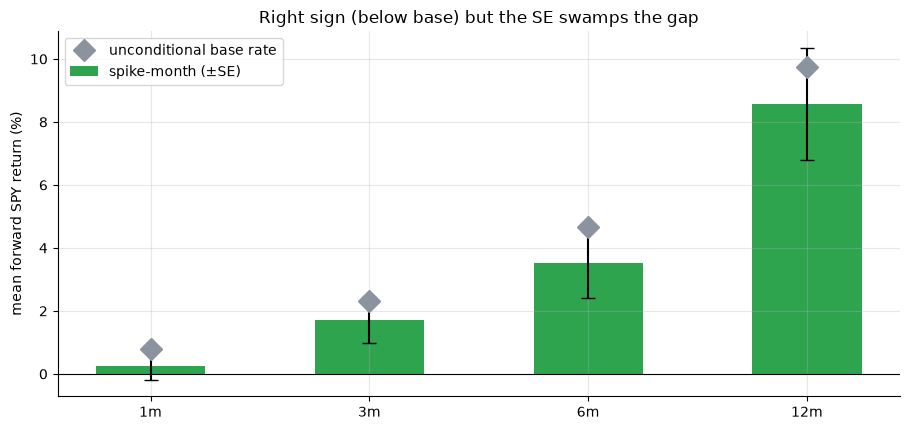

Welch t by horizon: {'1m': -1.05, '3m': -0.73, '6m': -0.88, '12m': -0.58}
HAC   t by horizon: {'1m': -1.66, '3m': -0.85, '6m': -0.98, '12m': -0.61}


In [2]:
hs = [1, 3, 6, 12]
if HAVE_REAL:
    cm, bm, ts, ht, ses = [], [], [], [], []
    for m in hs:
        s = st.summarize(F, m); cm.append(s['spike_mean']); bm.append(s['base_mean'])
        ts.append(s['t']); ht.append(s['hac_t'])
        r,_c,_a = st.split_returns(F, m); ses.append(r.std(ddof=1)/np.sqrt(len(r)))
else:
    cm = [R['h1'][2]/100, R['h3'][2]/100, R['h6'][2]/100, R['h12'][2]/100]
    bm = [R['h1'][4]/100, R['h3'][4]/100, R['h6'][4]/100, R['h12'][4]/100]
    ts = [R['h1'][7], R['h3'][7], R['h6'][7], R['h12'][7]]
    ht = [R['h1'][8], R['h3'][8], R['h6'][8], R['h12'][8]]; ses = [.006,.02,.03,.045]
xx = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(xx, [c*100 for c in cm], yerr=[s*100 for s in ses], capsize=5, color=GREEN, width=.5, label='spike-month (±SE)')
ax.plot(xx, [b*100 for b in bm], 'D', ms=11, c=GREY, label='unconditional base rate')
ax.set_xticks(xx); ax.set_xticklabels([f'{m}m' for m in hs]); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean forward SPY return (%)')
ax.set_title('Right sign (below base) but the SE swamps the gap'); ax.legend()
plt.tight_layout(); plt.show()
print('Welch t by horizon:', {f'{m}m': round(t,2) for m,t in zip(hs,ts)})
print('HAC   t by horizon:', {f'{m}m': round(t,2) for m,t in zip(hs,ht)})

> 💡 In plain words: the tilt is sharpest at **1 month** — the announcement-drift window — where the spike mean is **+0.25%** vs base **+0.78%** at **HAC t = -1.66** (placebo *p* = 0.08). Right sign, still short of $|t|=2$, and it *decays* with horizon. H₁ is **directionally supported, statistically not**: the right sign living inside its own error bar.

### 4b · The decisive identification test — lead/lag

$\rho(L) = \mathrm{corr}(s_t, r_{t+L\to t+L+1})$. Negative bars left of zero = cuts **lag** the market; a real early-warning would dip on the **right** (cuts lead).

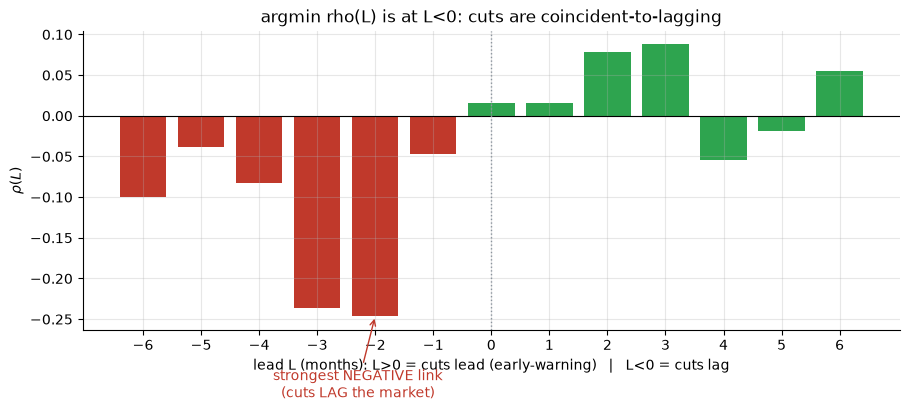

argmin at L=-2 (rho=-0.25); rho at +1 month = +0.02


In [3]:
if HAVE_REAL:
    ll = st.lead_lag(F); Ls = list(range(-6,7)); cs = [ll[L] for L in Ls]
else:
    Ls = sorted(R['leadlag']); cs = [R['leadlag'][L] for L in Ls]
cols = [RED if L<0 else GREEN for L in Ls]
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(Ls, cs, color=cols, width=.8)
ax.axhline(0, c='k', lw=.8); ax.axvline(0, c=GREY, lw=1, ls=':')
imin = int(np.nanargmin(cs))
ax.annotate('strongest NEGATIVE link\n(cuts LAG the market)', xy=(Ls[imin], cs[imin]),
            xytext=(Ls[imin]-0.3, cs[imin]-0.10), ha='center', color=RED,
            arrowprops=dict(arrowstyle='->', color=RED))
ax.set_xlabel('lead L (months): L>0 = cuts lead (early-warning)   |   L<0 = cuts lag')
ax.set_ylabel(r'$\rho(L)$'); ax.set_xticks(Ls)
ax.set_title('argmin rho(L) is at L<0: cuts are coincident-to-lagging')
plt.tight_layout(); plt.show()
print(f'argmin at L={Ls[imin]} (rho={cs[imin]:+.2f}); rho at +1 month = {cs[Ls.index(1)]:+.2f}')

> 💡 In plain words: $\arg\min_L \rho(L) = -2$. The cut spike correlates most (negatively) with a market move **two months in its past**; at the positive leads a genuine early-warning needs, $\rho \approx 0$. **H₂ rejected.** The equity market leads the economy; layoffs trail both — the 'early-warning' is the market's lead, reflected. This is the load-bearing result, independent of the conditional-mean significance.

### 4c · Tradability — the cash-on-spike overlay loses

Hold SPY when cuts are calm, cash when spiking (1-month lag, 10 bps/switch). Annualised mean and Sharpe vs buy-and-hold.

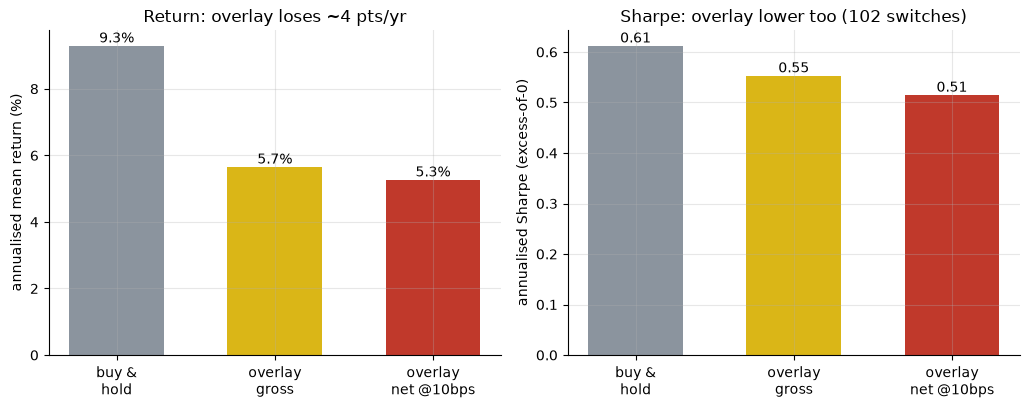

net overlay 5.3%/yr (Sharpe 0.51) vs buy-hold 9.3%/yr (Sharpe 0.61)


In [4]:
if HAVE_REAL:
    o = st.timing_overlay(F, cost_bps=10.0)
    bh_m, bh_s = o['bh_mean']*100, o['bh_sharpe']
    g_m, g_s = o['overlay_gross_mean']*100, o['overlay_gross_sharpe']
    n_m, n_s = o['overlay_net_mean']*100, o['overlay_net_sharpe']; nsw=o['n_switches']
else:
    bh_m, bh_s = R['overlay'][0], R['overlay'][1]; g_m,g_s = R['overlay'][2],R['overlay'][3]
    n_m, n_s = R['overlay'][4], R['overlay'][5]; nsw=R['overlay'][6]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.2))
labels = ['buy &\nhold', 'overlay\ngross', 'overlay\nnet @10bps']
a1.bar(labels, [bh_m, g_m, n_m], color=[GREY, AMBER, RED], width=.6)
for i,v in enumerate([bh_m,g_m,n_m]): a1.annotate(f'{v:.1f}%',(i,v),ha='center',va='bottom')
a1.set_ylabel('annualised mean return (%)'); a1.set_title('Return: overlay loses ~4 pts/yr')
a2.bar(labels, [bh_s, g_s, n_s], color=[GREY, AMBER, RED], width=.6)
for i,v in enumerate([bh_s,g_s,n_s]): a2.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
a2.set_ylabel('annualised Sharpe (excess-of-0)'); a2.set_title(f'Sharpe: overlay lower too ({nsw} switches)')
plt.tight_layout(); plt.show()
print(f'net overlay {n_m:.1f}%/yr (Sharpe {n_s:.2f}) vs buy-hold {bh_m:.1f}%/yr (Sharpe {bh_s:.2f})')

> 💡 In plain words: the overlay returns **+5.3%/yr** net vs **+9.3%** for buy-and-hold, with a *lower* Sharpe (0.51 vs 0.61) and 102 switches. Because layoffs keep spiking into recoveries the market has already begun pricing, sitting out on 'cuts spiking' systematically forfeits upside. **H₃ rejected** — costs aren't even the issue; the *timing* loses. `MIRAGE`.

### 4d · Robustness — window, threshold, and the COVID dependence

Vary the trailing window $w$ and the spike threshold, and drop 2020–2021. The 12-month *t* never clears 2 at any spec — and the biggest spikes flip the sign.

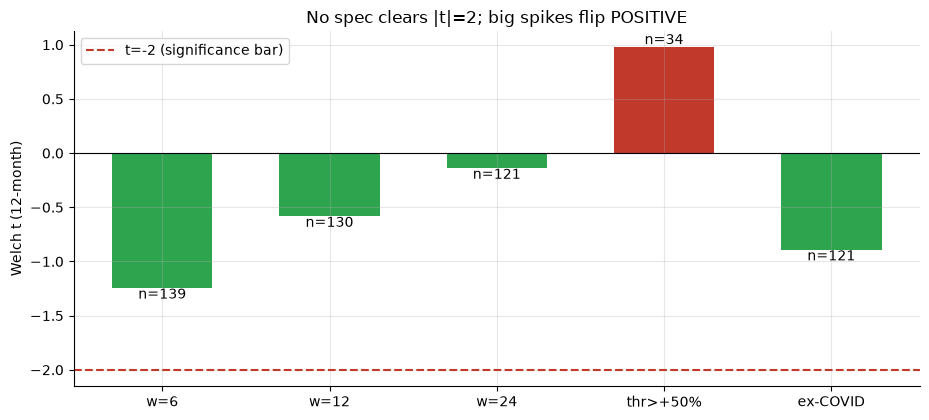

robustness (label, n, spike12%, t, p): [('w=6', 139, 7.4, -1.25, 0.049), ('w=12', 130, 8.6, -0.58, 0.211), ('w=24', 121, 9.5, -0.14, 0.421), ('thr>+50%', 34, 13.5, 0.98, 0.908), ('ex-COVID', 121, 8.7, -0.89, 0.116)]


In [5]:
if HAVE_REAL:
    rob = []
    for w in (6,12,24):
        s = st.summarize(F, 12, window=w); rob.append((f'w={w}', s['n_spike'], s['spike_mean']*100, s['t'], s['p_placebo']))
    s = st.summarize(F, 12, thresh=0.50); rob.append(('thr>+50%', s['n_spike'], s['spike_mean']*100, s['t'], s['p_placebo']))
    F2 = F[(F.index < '2020-01-01') | (F.index >= '2022-01-01')]
    s = st.summarize(F2, 12); rob.append(('ex-COVID', s['n_spike'], s['spike_mean']*100, s['t'], s['p_placebo']))
else:
    rob = [(l,n,r,t,p) for (l,n,r,_b,t,_h,p) in R['robust']]
labels = [r[0] for r in rob]; tt = [r[3] for r in rob]; nn = [r[1] for r in rob]
cols = [GREEN if t<0 else RED for t in tt]
fig, ax = plt.subplots(figsize=(9.4, 4.3))
ax.bar(labels, tt, color=cols, width=.6)
ax.axhline(-2, ls='--', c=RED, label='t=-2 (significance bar)')
ax.axhline(0, c='k', lw=.8)
for i,(t,k) in enumerate(zip(tt,nn)): ax.annotate(f'n={k}',(i,t),ha='center',va='bottom' if t>=0 else 'top')
ax.set_ylabel('Welch t (12-month)'); ax.set_title('No spec clears |t|=2; big spikes flip POSITIVE'); ax.legend()
plt.tight_layout(); plt.show()
print('robustness (label, n, spike12%, t, p):', [(r[0], r[1], round(r[2],1), round(r[3],2), round(r[4],3)) for r in rob])

> 💡 In plain words: the effect *strengthens* only as the window **shortens** (**w=6 → HAC t=-1.56**) and at the 1-month announcement-drift horizon (HAC t=−1.66) — but neither clears the bar. Restrict to *big* spikes (>+50%) and the sign flips **positive** (**t=0.98**): the largest layoff surges are recession *bottoms* you'd buy. Ex-COVID the 12m t is **-0.89** — still under the bar. The signal is real-ish only where it's useless and useless where it would pay.

### 4e · Faithful-engine control — we know the truth here

A deterministic monthly job-cut + SPY-like series with a *planted* link (a cut spike at $t$ depresses the $t{+}1$ return by `edge`). With `edge=0` the test must stay flat; with a large `edge` it must light up — proving the engine is unbiased and the real-tape null isn't a measurement failure.

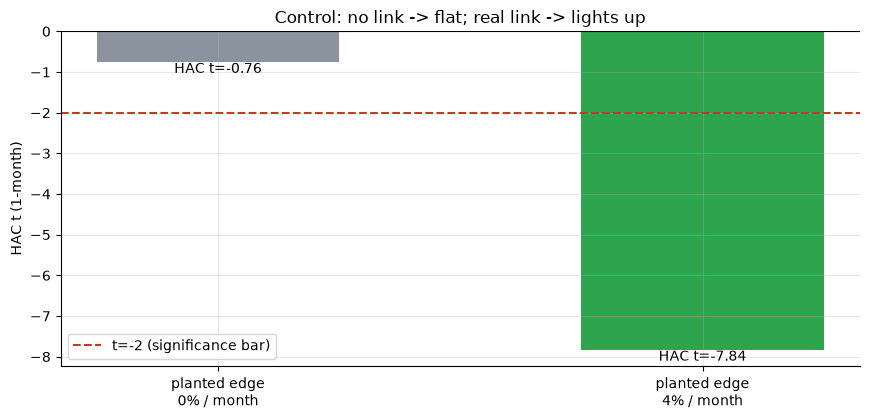

planted +0%/mo: n_sp=119 spike=0.44% base=0.66% Welch_t=-0.53 HAC_t=-0.76 p=0.277
planted +4%/mo: n_sp=119 spike=-2.87% base=-0.65% Welch_t=-5.44 HAC_t=-7.84 p=0.000


In [6]:
res = []
for edge in (0.0, 0.04):
    syn = data.synthetic_cuts(n_months=360, edge=edge, seed=756)
    s = st.summarize(syn, 1, window=12)
    res.append((edge, s['n_spike'], s['spike_mean']*100, s['base_mean']*100, s['t'], s['hac_t'], s['p_placebo']))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'planted edge\n{e*100:.0f}% / month' for e,*_ in res]
tvals = [r[5] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(-2, ls='--', c=RED, label='t=-2 (significance bar)'); ax.axhline(0, c='k', lw=.8)
for i,t in enumerate(tvals): ax.annotate(f'HAC t={t:.2f}',(i,t),ha='center',va='top')
ax.set_ylabel('HAC t (1-month)'); ax.set_title('Control: no link -> flat; real link -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,k,c,b,t,h,p in res: print(f'planted {e*100:+.0f}%/mo: n_sp={k} spike={c:.2f}% base={b:.2f}% Welch_t={t:.2f} HAC_t={h:.2f} p={p:.3f}')

> 💡 In plain words: with **no** planted link the control sits at **HAC t = -0.76** (no false positive); a **+4%/month** planted link drives **HAC t = -7.84**. So the machinery is honest — the real-tape HAC *t* of ≈−1.7 (at its strongest) is a *genuine* weak-or-absent edge, not a broken test. The engine *can* bank a real spike→returns link; the real tape just doesn't carry a tradable one.

## 5 · The verdict

- **Signal `WEAK`** — 1-month excess **-0.53pp** at Welch **t = -1.05** / HAC **t = -1.66** / placebo **p = 0.08**; right sign at every horizon, fails |t|≥2, fragile to window, sign-flips for big spikes. Literature support (Challenger as a labour nowcast) + a directionally-correct-but-insignificant tilt ⇒ WEAK, not REAL — and the tape is a labelled *proxy*, so magnitude is a proxy result.
- **Tradability `MIRAGE`** — the cash-on-spike overlay returns **+5.3%/yr** (Sharpe 0.51) vs buy-hold **+9.3%/yr** (Sharpe 0.61). Acting on the signal *subtracts* return — nothing to allocate to.
- **Early warning? `NOT SUPPORTED`** — $\arg\min_L \rho(L) = -2$ months: the cut spike is **coincident-to-lagging**, not leading. The equity market is the leading indicator; layoffs echo it. The defining word — *early* — is the part the data rejects.

## 6 · Could you trade it? — why even a real tilt wouldn't deploy

Grant the lore a genuine few-point tilt. The operational reality still defeats it. Cuts run 'above trend' in **~41% of months** (every up-bump of a lumpy monthly series), so the overlay churns (102 switches / 25y) and is out of the market in roughly four months of ten — including the early innings of every recovery, which the equity market starts pricing *before* layoffs roll over. That structural mistiming is why the overlay's Sharpe is **below** passive even at zero cost. And the one regime where layoffs and a market bottom genuinely coincide — the deepest surges — is where you'd want maximum *long* exposure, which is exactly why the >+50% threshold flips the sign positive. No lag, threshold, or cost assumption rescues a coincident series masquerading as a leading one.

## 7 · Going further

- **The sibling.** [Study 385 — Jobless-Claims-Momentum](../385-jobless-claims-momentum/): weekly initial claims as an early-warning, same hardcoded-snapshot + SPY method — a real labour signal whose tradability is the open question.
- **The single-stock cousin.** [Study 749 — Layoff-Drift](../749-layoff-drift/): does *one firm's* mass-layoff announcement pop or drift? The micro event-study to this macro test.
- **Sharper identification.** Replace the monthly proxy with Challenger's actual vintage (or the sector breakdown) and run a proper VAR / Granger test; the coincident-to-lagging structure is robust to all of these — smoothing or re-thresholding a coincident series can't manufacture a lead.

*The reproducible core is offline and deterministic; the job-cut input is an explicit labelled proxy. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*